<a href="https://colab.research.google.com/github/matteocaccia2001-source/Progetto-analisi-dati/blob/main/Progetto_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OBIETTIVO DEL PROGETTO

Immedesimandoci in manager di una banca internazionale ci chiediamo: Quali caratteristiche accomunano i clienti con la più alta probabilità di abbandonare la banca? Perchè se ne vanno?

In modo tale da attivare strategie di fidelizzazione mirate atte a diminuire la percentuale di clienti che abbandonano la banca

Vogliamo quindi effettuare un'analisi descrittiva e predittiva utilizzando un albero decisionale (classificazione) in quanto ci interessa sapere non solo se un cliente se ne andrà, ma soprattutto perché lo farà, identificando chiaramente le soglie e le condizioni logiche che portano all'abbandono.

## Informazioni dati contenuti nel dataset

Abbiamo utilizzato un dataset di benchmark standard per il settore bancario. I dati sono anonimizzati per garantire la privacy

RowNumber : Numero sequenziale per ogni record.

CustomerId : Identificativo univoco per ogni cliente.

Surname : Il cognome del cliente.

Geography : Il paese o la regione del cliente (es. Francia, Germania, Spagna).

Gender : Il sesso del cliente (Maschio/Femmina).

Age : L'età del cliente.

CreditScore : Il punteggio di credito del cliente (350–850).

Balance : Il saldo presente sul conto del cliente.

EstimatedSalary : Lo stipendio annuale stimato del cliente.

Tenure : Numero di anni da cui il cliente è con la banca.

NumOfProducts : Numero di prodotti bancari utilizzati dal cliente.

HasCrCard : Se il cliente possiede una carta di credito (0 = No, 1 = Sì).

IsActiveMember : Se il cliente è un membro attivo (0 = No, 1 = Sì).

Card Type : Il tipo di carta di credito (es. Visa, MasterCard).

Points Earned : Punti guadagnati dall'utilizzo della carta.

Satisfaction Score : Punteggio (1–5) dato dal cliente per la risoluzione dei reclami.

Exited : Se il cliente ha lasciato la banca (0 = Rimasto, 1 = Uscito).

LIBRERIA COMANDI PANDAS: https://pandas.pydata.org/docs/reference/frame.html

https://pandas.pydata.org/docs/reference/general_functions.html

LIBRERIA COMANDI GRAFICI PLT: https://matplotlib.org/stable/users/index.html

LIBRERIA COMANDI GRAFICI SNS: https://seaborn.pydata.org/tutorial.html

LIBRERIA COMANDI PREDIZIONE (SKLEARN): https://scikit-learn.org/stable/user_guide.html


# IMPORTAZIONE DEL DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Visualizzazione e Grafici
import matplotlib.pyplot as plt
import seaborn as sns

# Ottimizzazione Modello e Valutazione Performance
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix

# Modelli e Visualizzazione Albero
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
path = "/content/drive/MyDrive/progetto GARD/Bank Churn/"
df = pd.read_csv(path+"Bank_Churn.csv")

In [ ]:
# Creazione di una copia per la pulizia
data = df.copy()

# ANALISI DESCRITTIVA

CONTROLLO DEL DATASET

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


In [ ]:
data.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2,GOLD,339
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,3,DIAMOND,911


In [ ]:
data.shape

(10000, 17)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Satisfaction Score  10000 non-null  int64  
 15  Card Type           10000 non-null  object 
 16  Point

In [ ]:
# Analisi del numero di dati (frequenze)
print(data['Geography'].value_counts())
print(data['Gender'].value_counts())
print(data['Card Type'].value_counts())
print(data['Exited'].value_counts())
print(data['HasCrCard'].value_counts())
print(data['IsActiveMember'].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64
Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64
Exited
0    7962
1    2038
Name: count, dtype: int64
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


In [ ]:
data.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
# Rimozione colonne irrilevanti
irrelevant_columns = ['RowNumber', 'CustomerId', 'Surname']
data = data.drop(columns=irrelevant_columns)

In [ ]:
# Verifica quanti clienti hanno saldo 0
zeros = (data['Balance'] == 0).sum()
print(f"Clienti con Saldo 0: {zeros} su {len(data)}")


Clienti con Saldo 0: 3617 su 10000


Non dobbiamo elinimare gli zeri in Balance e neanche sostituirli con la media perchè molti clienti possono usare il conto anche senza depositare i risparmi. Andiamo quindi a creare una nuova colonna che specifica se il cliente ha risparmi sul conto oppure no, in modo da poter analizzare che chi ha un saldo positivo ha un comportamento di abbandono diverso da chi ha saldo pari a zero

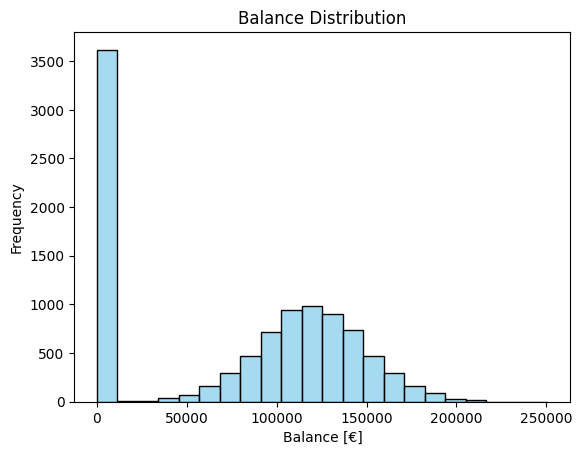

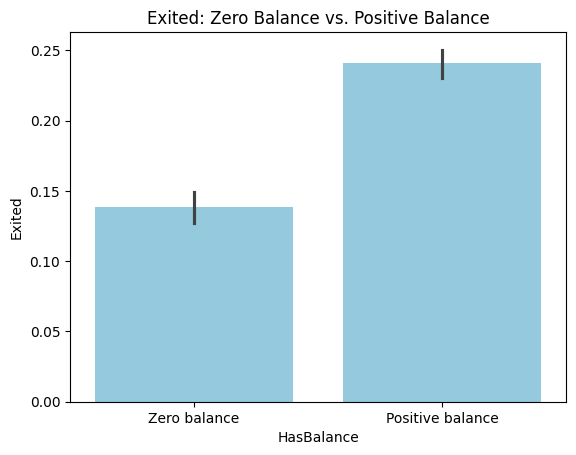

In [ ]:
# Creazione di una nuova colonna 'HasBalance'
data['HasBalance'] = (data['Balance'] > 0).astype(int)

# Grafico 1
sns.histplot(data['Balance'], color='skyblue')
plt.title('Balance Distribution')
plt.ylabel('Frequency')
plt.xlabel('Balance [€]')
plt.show()

# Grafico 2
sns.barplot(x='HasBalance', y='Exited', data=data, color='skyblue')
plt.title('Exited: Zero Balance vs. Positive Balance')
plt.xticks([0, 1], ['Zero balance', 'Positive balance'])
plt.show()

In [ ]:
# Controlliamo il dataset dopo le modifiche
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,HasBalance
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456,1
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425,1


ANALISI OUTLIERS

In [ ]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,HasBalance
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,3.013800,606.515100,0.638300
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,1.405919,225.924839,0.480517
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,1.000000,119.000000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,2.000000,410.000000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,3.000000,605.000000,1.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,4.000000,801.000000,1.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,5.000000,1000.000000,1.000000


Notiamo che in 'Estimated Salary' il valore minimo è 11,58 il che risulta strano, approfondiamo quindi l'analisi

In [ ]:
# Analisi di quante righe con salari annui inferiori a 1000
filtered_data = data[data['EstimatedSalary'] < 1000]
print(f"Numero di righe con EstimatedSalary < 1000: {filtered_data.shape[0]}")


Numero di righe con EstimatedSalary < 1000: 59


In [ ]:
# Eliminazione righe con salario annuo inferiore a 1000
data = data[data['EstimatedSalary'] >= 1000]

## GRAFICI E DOMANDE

**Che tipo di punteggio hanno i nostri clienti? Sono persone mediamente affidabili nel pagare i debiti o abbiamo troppi clienti rischiosi?**

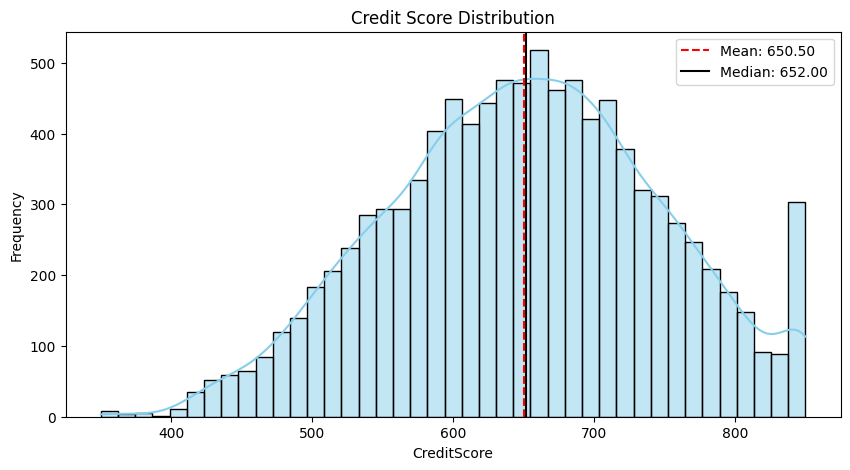

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data['CreditScore'], kde=True, color='skyblue')
plt.title('Credit Score Distribution')

mean_val = data['CreditScore'].mean()
median_val = data['CreditScore'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='black', linestyle='-', label=f'Median: {median_val:.2f}')
plt.legend()

plt.ylabel('Frequency')
plt.show()

Notiamo che la media (650.50) e la mediana (652.00) sono quasi coincidenti: questo indica una distribuzione bilanciata, la banca ha in media clienti con un medio-alto livello di credit score.

La coda sinistra del grafico (punteggi < 400) è poco popolata, suggerendo che i profili ad altissimo rischio di insolvenza sono una minoranza.

Un elemento interessante è il picco visibile all'estremo destro della distribuzione (in corrispondenza del valore 850). Questo accumulo di frequenze rappresenta un cluster specifico di clienti con il punteggio massimo possibile.

**Quanti anni hanno i nostri clienti? Siamo una banca frequentata soprattutto da giovani o da persone anziane?**

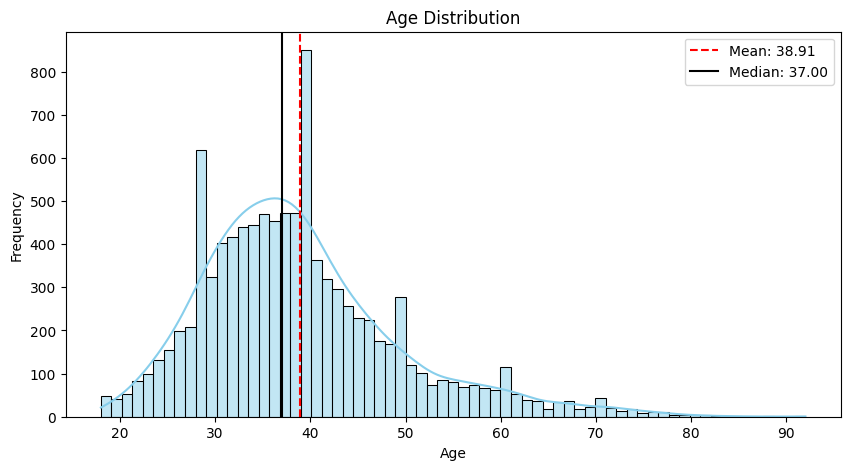

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data['Age'], kde=True, color='skyblue')
plt.title('Age Distribution')

mean_val = data['Age'].mean()
median_val = data['Age'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='black', linestyle='-', label=f'Median: {median_val:.2f}')
plt.legend()

plt.ylabel('Frequency')
plt.show()

La distribuzione mostra un picco nella fascia tra i 30 e i 40 anni. Questo ci conferma che la stragrande maggioranza dei nostri clienti è nel pieno della propria vita lavorativa e produttiva.

Abbiamo calcolato un'età media di circa 39 anni e una mediana di 37. Questa leggera differenza ci indica che, sebbene la "pancia" della clientela sia giovane, la presenza di clienti storici molto anziani tende ad alzare leggermente la media matematica.

**Quanto guadagnano i nostri clienti? Esiste una fascia di reddito predominante tra i nostri clienti?**

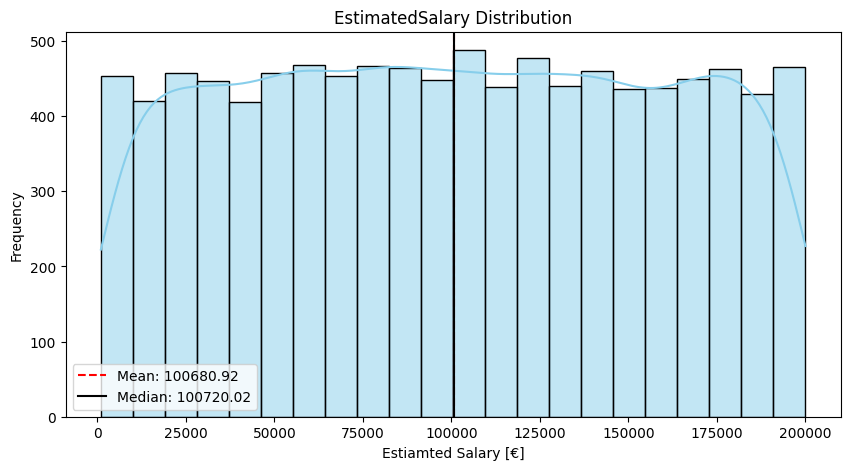

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data['EstimatedSalary'], kde=True, color='skyblue')
plt.title('EstimatedSalary Distribution')

mean_val = data['EstimatedSalary'].mean()
median_val = data['EstimatedSalary'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='black', linestyle='-', label=f'Median: {median_val:.2f}')
plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Estiamted Salary [€]')
plt.show()

A differenza di altre variabili, il reddito stimato presenta una distribuzione quasi uniforme (piatta). Questo ci indica che la banca non ha un target basato sul reddito. Non è una banca "per ricchi" né una banca "popolare".

Abbiamo rilevato che la media e la mediana sono quasi identiche. Questo è un segnale di grande equilibrio statistico: non ci sono redditi molto alti o redditi estremamente bassi.


**Da quanti anni i clienti stanno con noi? Abbiamo soprattutto clienti nuovi o clienti storici e fedeli?**

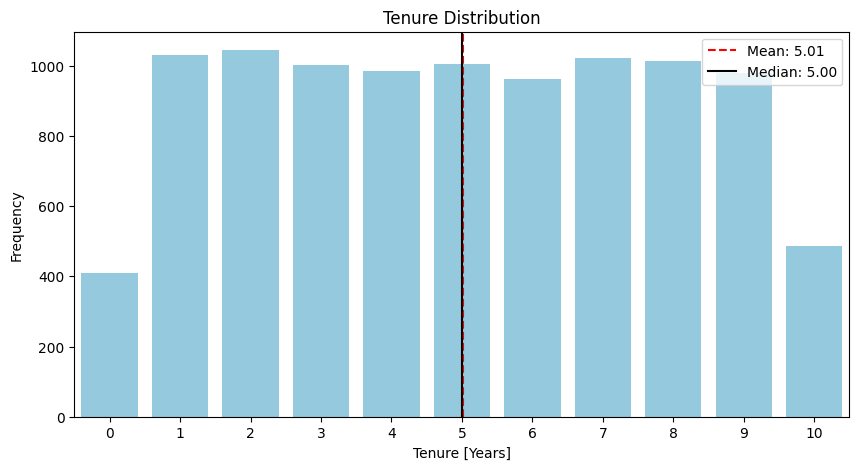

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x=data['Tenure'], color='skyblue')
plt.title('Tenure Distribution')

mean_val = data['Tenure'].mean()
median_val = data['Tenure'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='black', linestyle='-', label=f'Median: {median_val:.2f}')
plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Tenure [Years]')
plt.show()

Il grafico mostra una distribuzione estremamente uniforme tra 1 e 9 anni di permanenza. Questo ci indica che la banca è riuscita a mantenere un flusso costante di clienti nel tempo, senza subire "vuoti" o cali drastici in anni specifici.

Abbiamo rilevato che la media e la mediana coincidono quasi perfettamente. Per noi, questo è un segnale di grande stabilità: significa che esattamente la metà dei nostri clienti è con noi da almeno 5 anni, costituendo una base solida e matura.

Abbiamo notato una frequenza leggermente inferiore per i clienti appena arrivati (anno 0) e per i "fedelissimi" che hanno raggiunto i 10 anni. Riteniamo che questo dato suggerisca la necessità di migliorare sia l'accoglienza dei nuovi clienti sia le strategie di premio per chi supera il decennio di fedeltà, evitando che la relazione si esaurisca proprio sul traguardo dei 10 anni.

**Analizziamo la distribuzione della soddisfazione dei clienti, la banca riesce a soddisfare la maggior parte della sua utenza?**

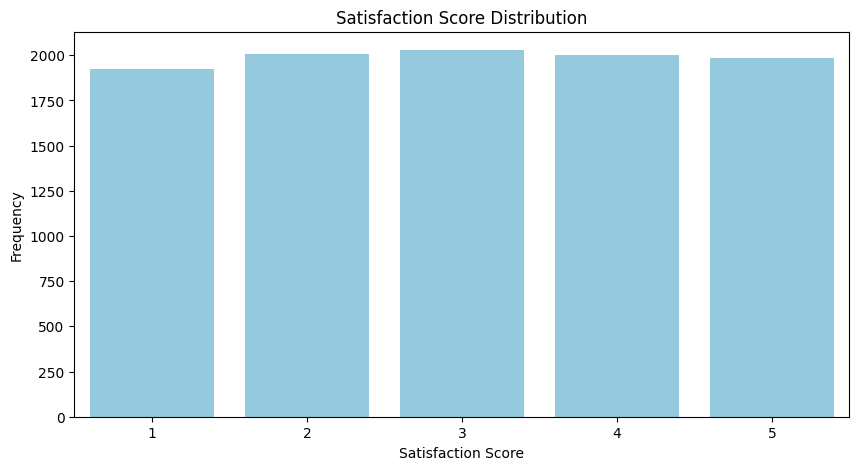

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x=data['Satisfaction Score'], color='skyblue')

plt.title('Satisfaction Score Distribution')
plt.ylabel('Frequency')
plt.show()

Notiamo la presenza di una distribuzione uniforme, non ci sono quindi clienti più arrabbiati o più felici.
Di conseguenza questo grafico ci fa pensare che questi dati potrebbero non essere determinanti per capire chi abbandona la banca

MATRICE DI CORRELAZIONE

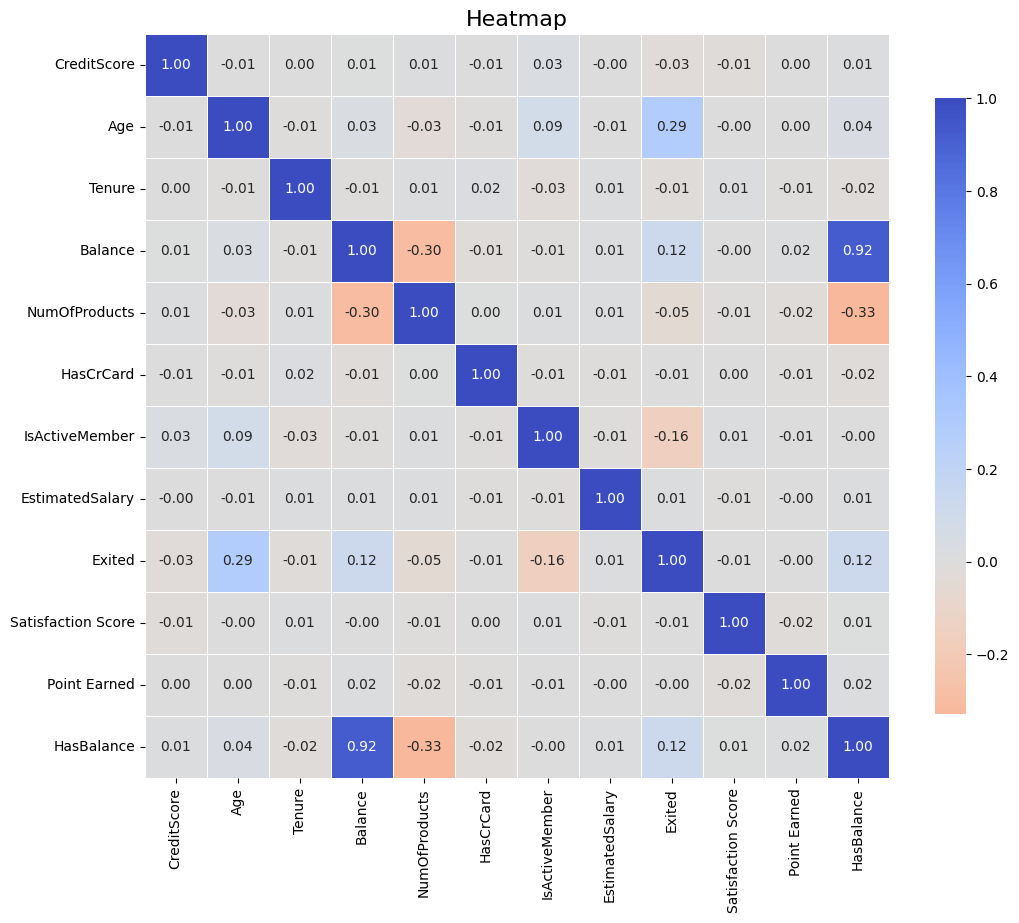

In [ ]:
#Selezione colonne numeriche
colonne_interesse = ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary','Exited','Satisfaction Score','Point Earned','HasBalance']

#Calcolo matrice di correlazione
corr_matrix = data[colonne_interesse].corr()

#Creazione heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm_r',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title('Heatmap', fontsize=16)
plt.show()

**Analisi della Matrice di Correlazione**

Questo strumento ci permette di individuare quanto e come le variabili si influenzino a vicenda, con valori che spaziano da -1 (correlazione negativa perfetta) a +1 (correlazione positiva perfetta).

Dall'analisi della heatmap emergono alcuni punti chiave:

**Relazione tra Age ed Exited (0.29):** Si nota una correlazione positiva moderata tra l'età e l'abbandono del cliente. Questo suggerisce che, all'aumentare dell'età, la probabilità che un cliente lasci la banca tende a crescere, rendendo l'età uno dei fattori predittivi più rilevanti per il nostro studio.

**Relazione tra Balance e Exited (0.12):** Esiste una correlazione positiva (seppur lieve) tra il saldo (Balance) e la variabile Exited. Questo dato è controintuitivo: indica che i clienti con conti più consistenti hanno una tendenza leggermente superiore ad abbandonare la banca rispetto a chi ha saldi bassi. Questo potrebbe suggerire che i clienti "più ricchi" siano anche i più esigenti o i più appetibili per la concorrenza.

**Correlazione tra NumOfProducts e Balance (-0.30):** Si osserva una correlazione negativa moderata che indica come i clienti con un numero maggiore di prodotti attivi tendano, paradossalmente, ad avere saldi più bassi o nulli. Questo suggerisce la presenza di una fascia di clienti "multi-prodotto" che utilizza il conto principalmente per operazioni tecniche o pagamenti di rate, mantenendo poca liquidità.

**IsActiveMember ed Exited (-0.16):** La correlazione negativa indica che i membri attivi abbandonano meno frequentemente la banca. Il dato conferma l'importanza strategica di mantenere alto il coinvolgimento del cliente per ridurne il tasso di uscita.

Inoltre notiamo che alcune variabili (Creditscore, Tenure, EstimatedSalary, Satisfaction score, ...) hanno una correlazione vicina allo zero con quasi tutte le altre variabili. Questo significa che non sembrano influenzare in modo diretto la decisione di restare o meno nella banca.

Andiamo ad approfondire alcune relazioni messe in evidenza dalla heatmap

**C'è una differenza di età tra chi decide di restare nella banca e chi invece decide di chiudere il conto? I clienti che abbandonano sono più giovani o più vecchi?**

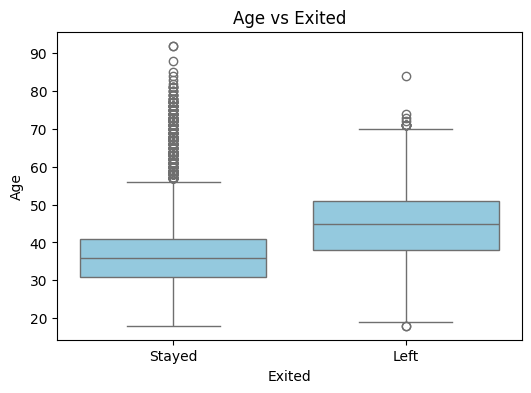

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x='Exited', y='Age', color='skyblue')

plt.title('Age vs Exited')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.xticks([0, 1], ['Stayed', 'Left'])

plt.show()

Abbiamo osservato che la box di chi ha lasciato la banca è posizionata più in alto rispetto a quella dei clienti rimasti. Questo ci conferma che, mediamente, i clienti che ci lasciano sono più anziani.

Mentre il cuore della clientela fedele si attesta tra i 30 e i 40 anni, abbiamo notato che il churn si concentra pesantemente tra i 40 e i 50 anni . Abbiamo identificato questo segmento come il più fragile, probabilmente perché più sensibile alle offerte della concorrenza o a diverse esigenze finanziarie.

I numerosi outliers sopra la box di chi resta indicano che esiste una porzione di clientela molto anziana che rimane fedele nonostante l'età avanzata . Questo ci ha suggerito che il rischio di abbandono non cresce all'infinito, ma si concentra in una specifica fase della vita adulta

**Impatto del Saldo sull' abbandono: il volume dei risparmi è un fattore discriminante per l'uscita del cliente?**

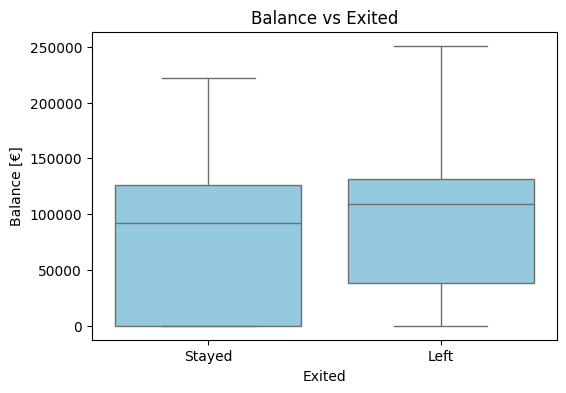

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x='Exited', y='Balance', color='skyblue')

plt.title('Balance vs Exited')
plt.xlabel('Exited')
plt.ylabel('Balance [€]')
plt.xticks([0, 1], ['Stayed', 'Left'])

plt.show()

Abbiamo notato che la box relativa ai clienti che hanno lasciato la banca è mediamente più alta e ha una mediana superiore rispetto a chi è rimasto. Questo ci indica che i clienti con risparmi più consistenti mostrano una propensione all'abbandono leggermente maggiore.

Il gruppo di sinistra mostra una forte concentrazione verso lo zero, il gruppo di chi abbandona mostra cifre più alte.

Per noi, questo è un dato allarmante dal punto di vista gestionale. Non stiamo perdendo solo clienti, ma stiamo perdendo i clienti che detengono la maggiore quota di capitale della banca.

**Il coinvolgimento del cliente influisce sulla sua fedeltà? Chi partecipa attivamente alla vita bancaria ha meno probabilità di lasciarci rispetto a chi è inattivo?**

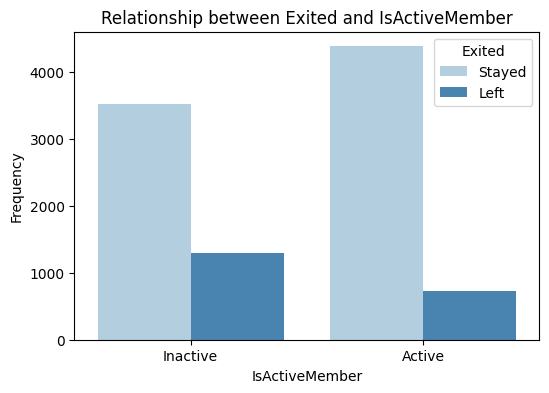

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='IsActiveMember', hue='Exited', palette="Blues")

plt.title('Relationship between Exited and IsActiveMember')
plt.xlabel('IsActiveMember')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['Inactive', 'Active'])
plt.legend(title='Exited', labels=['Stayed', 'Left'])

plt.show()

Il grafico mostra chiaramente che il numero di clienti che hanno abbandonato la banca (blu scuro) è sensibilmente inferiore tra i Membri Attivi rispetto ai Membri Inattivi.

Tra i membri definiti come "Inactive", abbiamo riscontrato una quota di abbandono molto più alta . Questo ci suggerisce che il disinteresse o il mancato utilizzo dei servizi sia il primo segnale di un imminente distacco definitivo.

Per noi, questo risultato evidenzia che la fedeltà non dipende solo dall' età e dalle condizioni economiche, ma anche dalla relazione quotidiana con l'istituto.

**In che modo il numero di prodotti posseduti e il livello di attività del cliente interagiscono tra loro? Esiste un numero 'ideale' di prodotti che massimizza la fedeltà?**

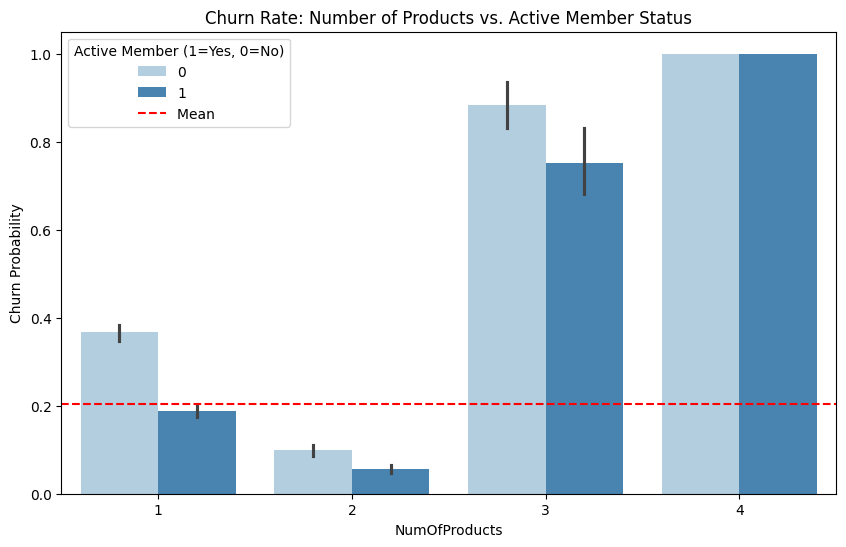

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='NumOfProducts', y='Exited', hue='IsActiveMember', data=data, palette='Blues')

plt.title('Churn Rate: Number of Products vs. Active Member Status')
plt.ylabel('Churn Probability')
plt.axhline(y=data['Exited'].mean(), color='red', linestyle='--', label='Mean ')
plt.legend(title='Active Member (1=Yes, 0=No)')

plt.show()

Abbiamo identificato che possedere 2 prodotti rappresenta la condizione di massima fedeltà per il cliente. In questo caso, il tasso di abbandono è minimizzato e scende significativamente sotto la media generale (linea rossa tratteggiata), indipendentemente dal fatto che il cliente sia attivo o meno.

Con nostra sorpresa, abbiamo notato che all'aumentare dei prodotti oltre la soglia dei due, il rischio di churn non diminuisce ma esplode. Chi possiede 3 prodotti ha una probabilità altissima di lasciarci, e per chi ne ha 4 l'abbandono è pressoché certo. Ipotizziamo che un numero eccessivo di prodotti possa indicare una gestione complessa o insoddisfacente dei servizi bancari.

Abbiamo osservato che essere un Membro Attivo riduce sensibilmente la probabilità di abbandono, specialmente per chi ha 1 o 3 prodotti . Tuttavia, l'attività non è sufficiente a salvare i clienti con 4 prodotti, che se ne vanno in ogni caso.

Per noi, questo grafico suggerisce una strategia commerciale chiara: la banca non deve spingere i clienti verso un numero eccessivo di prodotti, ma puntare a stabilizzarli sulla soglia dei 2 prodotti, cercando contemporaneamente di stimolare l'attività per chi ne possiede solo uno.

# ANALISI PREDITTIVA

ENCODING DELLE COLONNE NON NUMERICHE

In [ ]:
#One-Hot Encoding
data_encoded = pd.get_dummies(data, columns=['Geography', 'Gender', 'Card Type'])

In [ ]:
data_encoded.head(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,...,HasBalance,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,1,2,...,0,True,False,False,True,False,True,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,3,...,1,False,False,True,True,False,True,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,3,...,1,True,False,False,True,False,True,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,5,...,0,True,False,False,True,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,5,...,1,False,False,True,True,False,False,True,False,False
5,645,44,8,113755.78,2,1,0,149756.71,1,5,...,1,False,False,True,False,True,True,False,False,False
6,822,50,7,0.00,2,1,1,10062.80,0,2,...,0,True,False,False,False,True,False,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,1,2,...,1,False,True,False,True,False,True,False,False,False
8,501,44,4,142051.07,2,0,1,74940.50,0,3,...,1,True,False,False,False,True,False,True,False,False
9,684,27,2,134603.88,1,1,1,71725.73,0,3,...,1,True,False,False,False,True,False,True,False,False


CROSS-VALIDATION

Il codice contenuto nella cella successiva è stato elaborato con il supporto di strumenti di Intelligenza Artificiale. La logica dello script è stata successivamente compresa e verificata per garantirne la correttezza del progetto

In [ ]:
# Creazione del set di training
X = data_encoded.drop(columns=['Exited'])
y = data_encoded['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CROSS VALIDATION (10-FOLD)
results = []
depths = range(1, 21)  # Testiamo profondità da 1 a 20

for depth in depths:
    # Inizializziamo l'albero con la profondità corrente
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42, min_samples_leaf=20)

    # Eseguiamo la validazione incrociata a 10 fold
    # Nota: Usiamo 'accuracy' come metrica
    scores = cross_val_score(clf, X_train, y_train, cv=10, scoring='accuracy')

    # Salviamo i risultati
    results.append({
        'Max Depth': depth,
        'Accuracy Media': scores.mean()
    })

# CREAZIONE E STAMPA TABELLA
results_df = pd.DataFrame(results)
results_df.set_index('Max Depth', inplace=True)

print("\n--- Risultati Cross Validation ---")
print(results_df.round(2))


--- Risultati Cross Validation ---
           Accuracy Media
Max Depth                
1                    0.80
2                    0.83
3                    0.84
4                    0.85
5                    0.85
6                    0.86
7                    0.85
8                    0.85
9                    0.84
10                   0.84
11                   0.84
12                   0.84
13                   0.84
14                   0.84
15                   0.84
16                   0.84
17                   0.84
18                   0.84
19                   0.84
20                   0.84


Notiamo che la profondità ottimale è 6, effettuiamo una verifica per validare il risultato ottenuto

VERIFICA (CROSS-VALIDATION AUTOMATICA)

Il codice contenuto nella cella successiva è stato elaborato con il supporto di strumenti di Intelligenza Artificiale. La logica dello script è stata successivamente compresa e verificata per garantirne la correttezza del progetto

In [ ]:
# 1. Definiamo la griglia dei parametri da testare
#    (sostituisce il 'range(1, 21)' del ciclo for)
param_grid = {
    'max_depth': range(1, 21)
}

# 2. Inizializziamo il modello base (senza specificare la profondità fissa)
base_tree = DecisionTreeClassifier(random_state=42, min_samples_leaf=20)

# 3. Configuriamo la Grid Search
grid_search = GridSearchCV(
    estimator=base_tree,       # Il modello da usare
    param_grid=param_grid,     # I parametri da provare
    cv=10,                     # 10-Fold Cross Validation
    scoring='accuracy',        # Metrica di valutazione
    n_jobs=-1                  # Usa tutti i processori per fare prima
)

# 4. Addestriamo
grid_search.fit(X_train, y_train)

# --- RISULTATI ---

print(f"\nLa migliore profondità trovata è: {grid_search.best_params_['max_depth']}")
print(f"Accuracy media migliore: {grid_search.best_score_:.2f}")

# 5. Creiamo la tabella dei risultati per vederli tutti
results_df = pd.DataFrame(grid_search.cv_results_)

# Puliamo la tabella per tenere solo quello che ci interessa
table_view = results_df[['param_max_depth', 'mean_test_score']].copy()
table_view.columns = ['Max Depth', 'Accuracy Media']
table_view.set_index('Max Depth', inplace=True)

print("\nRisultati Cross Validation (Grid Search)")
print(table_view.round(2))


La migliore profondità trovata è: 6
Accuracy media migliore: 0.86

Risultati Cross Validation (Grid Search)
           Accuracy Media
Max Depth                
1                    0.80
2                    0.83
3                    0.84
4                    0.85
5                    0.85
6                    0.86
7                    0.85
8                    0.85
9                    0.84
10                   0.84
11                   0.84
12                   0.84
13                   0.84
14                   0.84
15                   0.84
16                   0.84
17                   0.84
18                   0.84
19                   0.84
20                   0.84


Anche la verifica automatica conferma che la profondità 6 risulta essere l'ottimo teorico. Tuttavia, selezioniamo max_depth = 4 per avere maggiore chiarezza: la differenza di accuratezza è trascurabile, mentre un albero più contenuto garantisce una migliore interpretabilità.

ALBERO DECISIONALE: CLASSIFICAZIONE

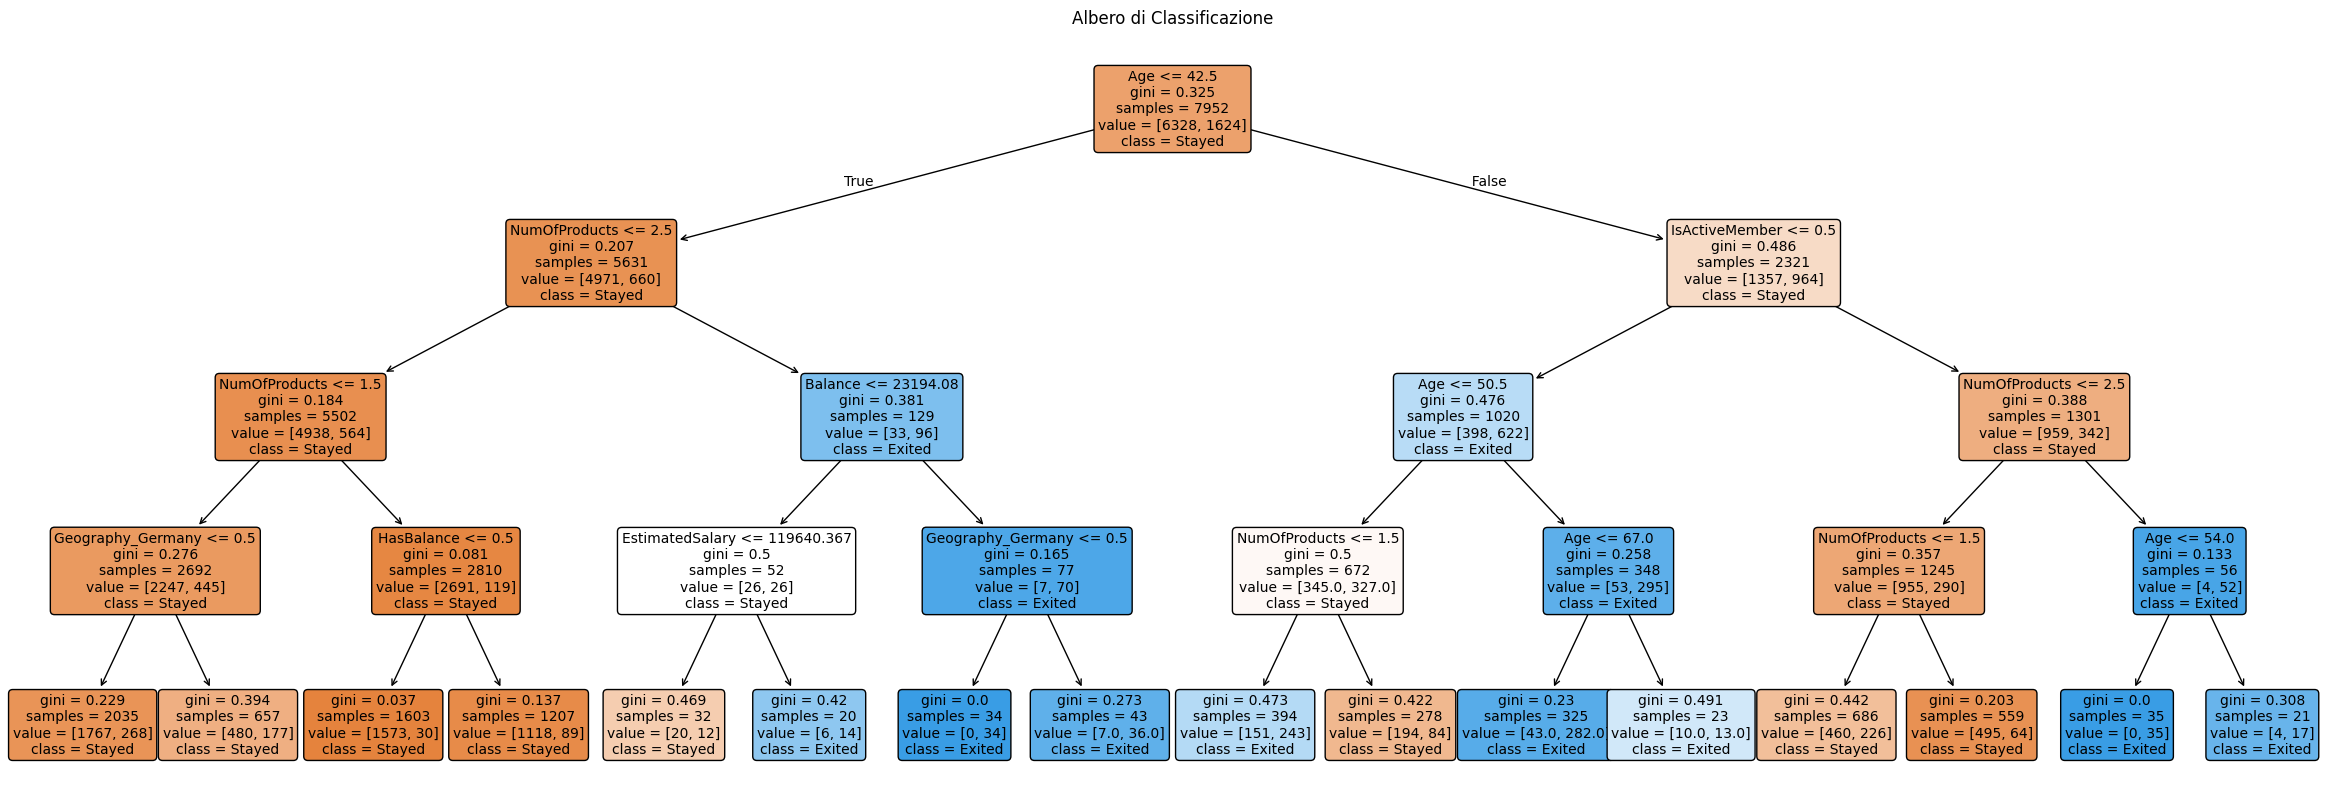

In [ ]:
# Addestramento dell'Albero di Classificazione

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_leaf=20)
dt_model.fit(X_train, y_train)

# Visualizzazione dell'Albero

plt.figure(figsize=(30, 10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Stayed', 'Exited'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Albero di Classificazione")
plt.show()

ANALISI ALBERO DECISIONALE

**1- Il criterio anagrafico (Root Node)**

Il nodo radice identifica l'Età <= 42.5 come la variabile con il massimo potere discriminante.

- Ramo Sinistro (True): Se il cliente è giovane (≤ 42.5 anni), viene
classificato prevalentemente come fedele (Stayed). La giovinezza si conferma il principale fattore di stabilità.

- Ramo Destro (False): Se il cliente è più maturo (> 42.5 anni), viene incanalato a destra, dove il rischio di abbandono aumenta sensibilmente.

**2- Giovani e Saturazione dei prodotti**

Nel ramo dei giovani, il possesso di troppi prodotti è un chiaro segnale di allarme. Se un cliente giovane possiede più di 2 prodotti (nodo NumOfProducts <= 2.5 False), finisce in un nodo critico intermedio (Balance <= 23194.08). Qui, su 129 campioni totali, ben 96 abbandonano (pari al 74.4% di churn). Questo indica che l'eccesso di prodotti (3 o 4) è indice di instabilità anche nella fascia d'età più sicura.

*Analisi Geografica:* Per chi ha un numero standard di prodotti (1 o 2), la Germania mostra una maggiore volatilità. Il nodo relativo ai clienti "Non Germania" (Francia/Spagna) con 1 prodotto è estremamente stabile (Gini 0.229, 268 uscite su 2035 casi), mentre il corrispettivo tedesco ha un Gini più alto (0.394) e un tasso di abbandono quasi doppio.

**3- Analisi del Segmento Senior (Age > 42.5)**

Questo ramo rappresenta la massima criticità per la banca. Il nodo genitore (IsActiveMember <= 0.5) mostra che su 2.321 clienti senior totali, ben 964 sono usciti (incidenza del 41.5%).

L'importanza dell'Engagement: La situazione peggiora drasticamente se il cliente over 42 non è attivo.

Rischio Medio-Alto (42.5 - 50.5 anni): Per i clienti inattivi in questa fascia che possiedono un solo prodotto, il rischio è molto elevato: su 394 campioni, 243 sono usciti (61.7%).

Il Picco Assoluto di Rischio (50.5 - 67 anni): Seguendo il percorso dei clienti inattivi più anziani, si arriva alla foglia blu scuro (nodo terminale sotto Age <= 67.0). In questo gruppo specifico, su 325 campioni, ben 282 hanno abbandonato la banca e solo 43 sono rimasti. Con un tasso di abbandono dell'86.8%, questo è il segmento peggiore in assoluto.

**Conclusioni del Modello**

Foglie Arancioni Scure (Safe Zones - Fedeltà): Il profilo di massima sicurezza è il cliente giovane (≤ 42 anni) con 2 prodotti. In particolare, se questo cliente ha un saldo a zero (HasBalance <= 0.5 True), il modello raggiunge la massima purezza (Indice di Gini 0.037), mentre con saldo positivo la fedeltà rimane comunque molto alta (Gini 0.137).

Foglie Blu (Danger Zones - Abbandono): Il rischio si concentra su due assi principali:

- Senior Inattivi (50-67 anni): I clienti inattivi tra i 50 e i 67 anni hanno una probabilità di abbandono dell'87% (282 uscite su 325 casi).

- Eccessivo numero di prodotti: A prescindere dall'età, avere troppi prodotti spinge il cliente verso l'abbandono (96 uscite su 129 casi nel cluster dei giovani "sovraccarichi").

Il codice contenuto nella cella successiva è stato elaborato con il supporto di strumenti di Intelligenza Artificiale. La logica dello script è stata successivamente compresa e verificata per garantirne la correttezza del progetto

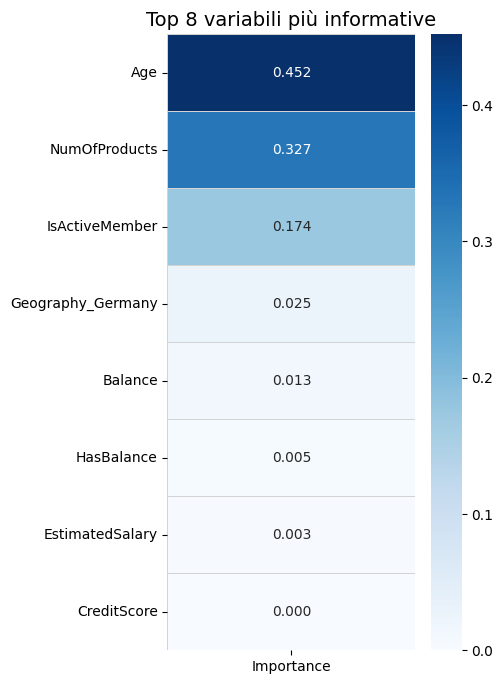

In [ ]:
# 1. Recuperiamo importanze e nomi
importances = dt_model.feature_importances_
feature_names = X.columns

# 2. Creiamo il DataFrame e lo ordiniamo subito
heatmap_data = pd.DataFrame(importances, index=feature_names, columns=['Importance'])
heatmap_data = heatmap_data.sort_values(by='Importance', ascending=False)

# 3. SELEZIONIAMO SOLO LE PRIME 8 (Le più potenti)
heatmap_data_top8 = heatmap_data.head(8)

# 4. Generiamo la Heatmap
plt.figure(figsize=(4, 8)) # Dimensioni ottimizzate per 8 righe
sns.heatmap(heatmap_data_top8,
            annot=True,
            cmap='Blues',
            fmt='.3f',
            cbar=True,
            linewidths=0.5,
            linecolor='lightgray')

plt.title('Top 8 variabili più informative', fontsize=14)
plt.show()

ANALISI DELLE PERFORMANCE

In [ ]:
# Calcolo delle predizioni
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calcolo dell'Accuracy
test_acc = accuracy_score(y_test, y_test_pred)
train_acc = accuracy_score(y_train, y_train_pred)

# Calcolo dell'overfitting (gap)
overfitting_gap = train_acc - test_acc

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Overfitting gap:   {overfitting_gap:.4f}")


Training Accuracy: 0.8527
Test Accuracy:     0.8426
Overfitting gap:   0.0101


Confrontando l'accuracy di train e di test possiamo notare un modello robusto e ben generalizzato. L'accuratezza sul dataset di addestramento (0.8527) è estremamente vicina a quella sul dataset di test (0.8426), con un divario minimo.

L'assenza di un gap significativo indica che il modello non soffre di overfitting, di conseguenza il modello non si è limitato a memorizzare i dati di training, ma ha appreso dei pattern che risultano validi anche su dati non ancora osservati.

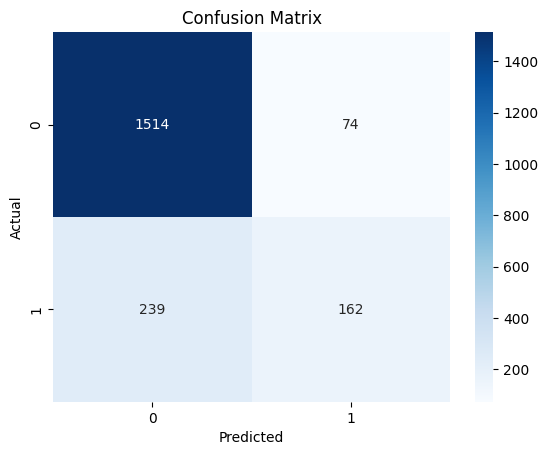

In [ ]:
# Valutazione del Modello con matrice di confusione
y_pred = dt_model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

METRICHE DI PERFORMANCE

PRECISION (precisione):

Precision = TP / TP + FP = 162 / 236 ≈ 69%

RECALL (stabilità):

Recall = TP / TP + FN = 162 / 401 ≈ 40%

Possiamo subito notare che il modello è molto solido nel riconoscere la classe 0, con oltre 1500 predizioni corrette (ovvero il caso in cui il cliente non abbandona la banca). Tuttavia analizzando le metriche di performance notiamo che:

**Analisi della Precision (~69%)** Una Precision del 70% rappresenta un risultato positivo in termini di affidabilità. Questo dato indica che il modello è preciso nel lanciare allarmi: circa 7 volte su 10, quando l'algoritmo prevede l'abbandono di un cliente, la previsione si rivela corretta. Dal punto di vista operativo, questo implica un'alta efficienza, poiché riduce lo spreco di risorse su clienti che in realtà sono fedeli (pochi Falsi Positivi).

**Analisi della Recall (~40%)** Al contrario, una Recall del 40% è un valore critico per la nostra analisi. Un valore così basso segnala che l'algoritmo ha una scarsa capacità di copertura: il 60% dei clienti a rischio sfugge al rilevamento ("Falsi Negativi"). In termini di business, questo rappresenta un problema significativo, poiché la banca non sarà in grado di intervenire per trattenere la maggior parte dei clienti in uscita, subendo una perdita economica diretta.

## SECONDO SCENARIO ( ALBERO DI CLASSIFICAZIONE CON CLASS WEIGHT BALANCED)

**Il Problema:** L'analisi ha evidenziato un numero eccessivo di Falsi Negativi. Il modello base, addestrato su un dataset nel quale i clienti fedeli sono la maggioranza, tende a privilegiare la classe dominante, ignorando gran parte dei clienti a rischio abbandono.

Un sistema che lascia sfuggire il 60% dei clienti a rischio (Falsi Negativi) vanifica l'utilità stessa del progetto e del nostro obiettivo, poiché la banca perderebbe la maggior parte dei clienti insoddisfatti senza avere nemmeno l'opportunità di intervenire.

**Ricerca della Soluzione (Supporto IA):** Identificata la criticità (bassa Recall), ma non disponendo nell'immediato di una strategia tecnica correttiva, ci siamo avvalsi del supporto dell'Intelligenza Artificiale. Abbiamo sottoposto all'IA il problema dello sbilanciamento evidenziato dalla matrice, chiedendo quali parametri potessero incrementare la sensibilità del modello senza alterare i dati originali. L'IA ci ha suggerito di intervenire sull'iperparametro class_weight='balanced'

**Implementazione e Obiettivo:** Seguendo questo suggerimento, abbiamo introdotto il parametro. La nostra priorità strategica è quella di massimizzare la capacità di intercettazione (Recall), spostando il focus del modello dalla precisione pura alla sensibilità. Questa configurazione impone al modello di dare maggiore importanza agli errori commessi sulla classe minoritaria (Exited).

**Spiegazione Tecnica:** L'attivazione di questo parametro modifica la percezione del modello: fa sì che i clienti che abbandonano abbiano un peso specifico molto più alto, costringendo l'algoritmo a trattarli con la stessa attenzione riservata a chi rimane. Il campo 'value' non rappresenta più il conteggio grezzo delle persone fisiche, bensì una somma ponderata.

In questo modo, il modello è matematicamente costretto a trattare le due classi come se avessero la stessa importanza, compensando la scarsità numerica con un peso maggiore.

CROSS-VALIDATION

Il codice contenuto nella cella successiva è stato elaborato con il supporto di strumenti di Intelligenza Artificiale. La logica dello script è stata successivamente compresa e verificata per garantirne la correttezza del progetto

In [ ]:
# 1. Definiamo la griglia dei parametri da testare
param_grid = {
    'max_depth': range(1, 21)
}

# 2. Inizializziamo il modello base (senza specificare la profondità fissa)
base_tree = DecisionTreeClassifier(random_state=42, class_weight = 'balanced', min_samples_leaf=20)

# 3. Configuriamo la Grid Search
grid_search = GridSearchCV(
    estimator=base_tree,       # Il modello da usare
    param_grid=param_grid,     # I parametri da provare
    cv=10,                     # 10-Fold Cross Validation
    scoring='accuracy',        # Metrica di valutazione
    n_jobs=-1                  # Usa tutti i processori per fare prima
)

# 4. Addestriamo
grid_search.fit(X_train, y_train)

# --- RISULTATI ---

print(f"\nLa migliore profondità trovata è: {grid_search.best_params_['max_depth']}")
print(f"Accuracy media migliore: {grid_search.best_score_:.2f}")

# 5. Creiamo la tabella dei risultati per vederli tutti
results_df = pd.DataFrame(grid_search.cv_results_)

# Puliamo la tabella per tenere solo quello che ci interessa
table_view = results_df[['param_max_depth', 'mean_test_score']].copy()
table_view.columns = ['Max Depth', 'Accuracy Media']
table_view.set_index('Max Depth', inplace=True)

print("\nRisultati Cross Validation (Grid Search)")
print(table_view.round(3))


La migliore profondità trovata è: 6
Accuracy media migliore: 0.77

Risultati Cross Validation (Grid Search)
           Accuracy Media
Max Depth                
1                   0.720
2                   0.727
3                   0.734
4                   0.752
5                   0.752
6                   0.774
7                   0.763
8                   0.768
9                   0.768
10                  0.770
11                  0.762
12                  0.758
13                  0.758
14                  0.757
15                  0.757
16                  0.757
17                  0.757
18                  0.757
19                  0.757
20                  0.757


Dall'analisi della Cross Validation, la profondità 6 risulta essere l'ottimo teorico. Tuttavia, selezioniamo max_depth = 4 per avere maggiore chiarezza: la differenza di accuratezza è trascurabile, ma un albero più contenuto garantisce una migliore interpretabilità.

ALBERO DECISIONALE: CLASSIFICAZIONE

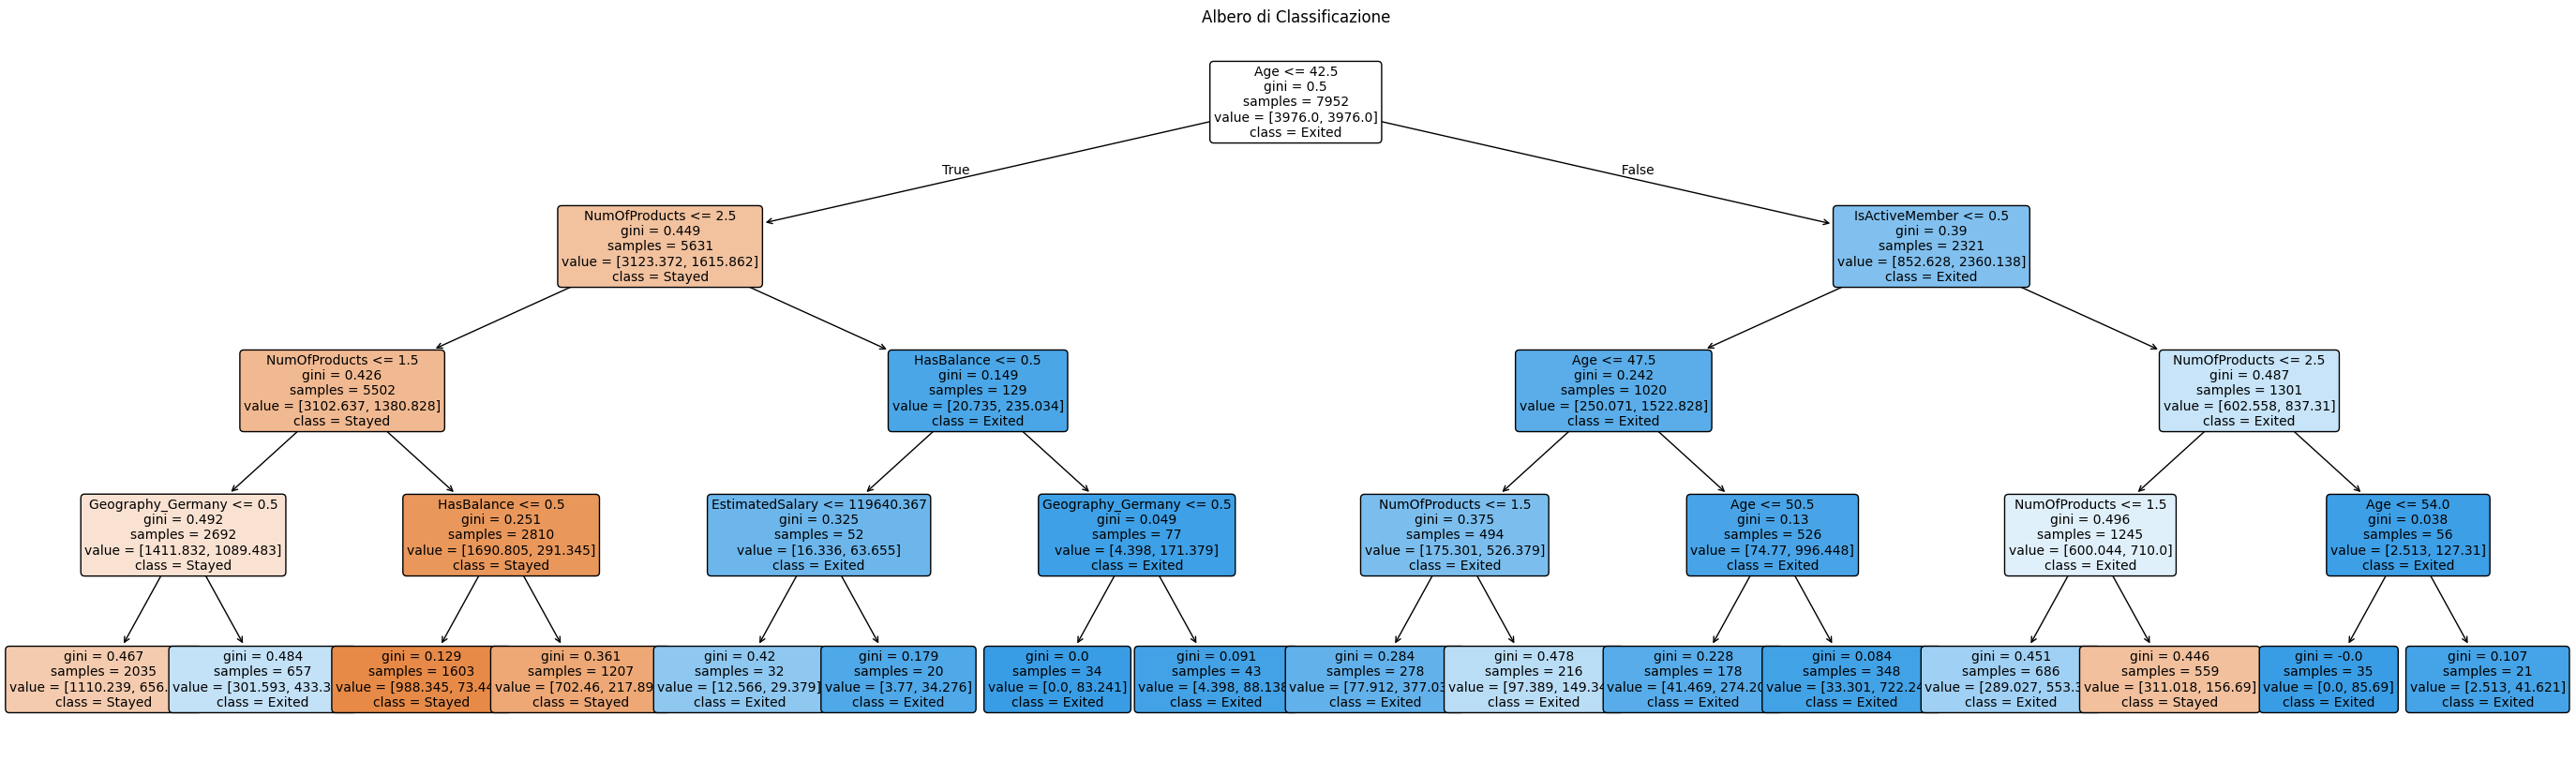

In [ ]:
# Addestramento dell'Albero di Classificazione

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced', min_samples_leaf=20)
dt_model.fit(X_train, y_train)

# Visualizzazione dell'Albero

plt.figure(figsize=(35, 10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Stayed', 'Exited'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Albero di Classificazione")
plt.show()

ANALISI ALBERO DECISIONALE (class_weight = 'balanced')

L'attivazione del parametro balanced modifica i valori all'interno dei nodi (value). Non leggiamo più il numero esatto di persone, ma un punteggio ponderato che equipara artificialmente l'importanza di chi resta e di chi se ne va. Nel nodo radice, infatti, vediamo che su 7952 campioni, il valore è perfettamente diviso: [3976.0, 3976.0]. Il modello parte da un'ipotesi di 50/50.

Di seguito analizziamo le differenze rispetto al primo albero:

**1-Il ramo inerente alla germania:** Da Safe Zone a Rischio

Nel primo albero, i clienti giovani tedeschi con 1 prodotto erano classificati come "Stayed" (arancioni). In questo nuovo albero bilanciato, osserviamo un cambiamento drastico nel ramo sinistro (Age <= 42.5 -> NumOfProducts <= 1.5 -> Germany > 0.5):

I clienti sono sempre 657 ma ora il modello attribuisce al gruppo "Stayed" un valore di 301.59 e al gruppo "Exited" un valore di 433.3.
Il nodo diventa BLU (Exited).

- Interpretazione: Anche se numericamente ci sono più persone che restano, il modello "bilanciato" giudica quei 177 che escono (visti nell'albero precedente) come molto più gravi e importanti. La Germania diventa ufficialmente una zona a rischio anche per i giovani.

**2-I Senior Attivi non sono più al sicuro** Nel primo scenario, essere un "Membro Attivo" salvava molti clienti over 42. Qui la protezione crolla. Guardiamo il ramo destro (Age > 42.5):

- Il nodo genitore dei Senior parte già con una previsione di abbandono massiccia (Valore pesato: 852 Stayed vs 2360 Exited).

- Scendendo verso i membri attivi (IsActiveMember <= 0.5 False -> ramo destro), vediamo che il nodo risultante è BLU rispetto a prima che era arancione

- Anche nel gruppo dei Senior Attivi con pochi prodotti (NumOfProducts <= 2.5), il modello vede un rischio latente molto più alto rispetto al primo albero.

**3-Saturazione Prodotti:** Se nel primo albero i giovani con troppi prodotti (> 2.5) erano un rischio, qui diventano una certezza assoluta di perdita.

In particolare, chi ha saldo zero e troppi prodotti ha un valore pesato di 20.7 Stayed contro 235.0 Exited.

**4-Nuovi Criteri di separazione** Essendo più sensibile al rischio, l'albero ha cambiato alcune soglie d'età per intercettare prima i problemi:

Nel ramo destro (Senior inattivi), il primo taglio sull'età non è più 50.5, ma si abbassa a 47.5 anni (Age <= 47.5).

Questo significa che il modello inizia a considerare "critica" l'inattività molto prima rispetto al modello standard.

*Si nota che i valori del campo 'value' presentano cifre decimali. Ciò è dovuto all'iperparametro class_weight='balanced', che sostituisce il conteggio dei campioni con la somma ponderata dei loro pesi.*

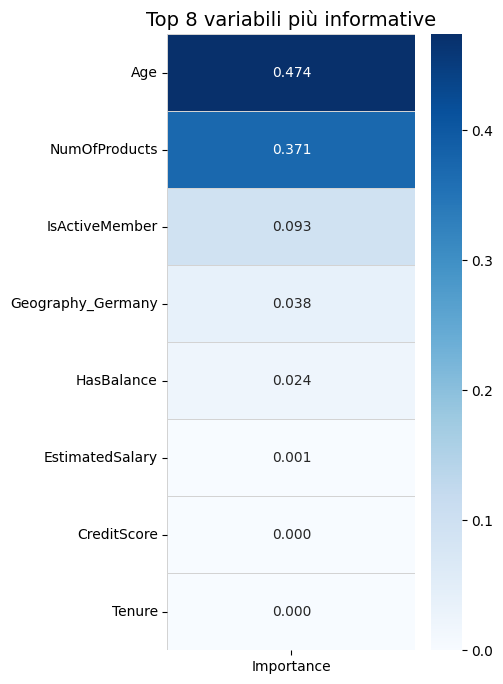

In [ ]:
# 1. Recuperiamo importanze e nomi
importances = dt_model.feature_importances_
feature_names = X.columns

# 2. Creiamo il DataFrame e lo ordiniamo subito
heatmap_data = pd.DataFrame(importances, index=feature_names, columns=['Importance'])
heatmap_data = heatmap_data.sort_values(by='Importance', ascending=False)

# 3. SELEZIONIAMO SOLO LE PRIME 8 (Le più potenti)
heatmap_data_top8 = heatmap_data.head(8)

# 4. Generiamo la Heatmap
plt.figure(figsize=(4, 8)) # Dimensioni ottimizzate per 8 righe
sns.heatmap(heatmap_data_top8,
            annot=True,
            cmap='Blues',
            fmt='.3f',
            cbar=True,
            linewidths=0.5,
            linecolor='lightgray')

plt.title('Top 8 variabili più informative', fontsize=14)
plt.show()

ANALISI DELLE PERFORMANCE

In [ ]:
# Calcolo delle predizioni
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calcolo dell'Accuracy
test_acc = accuracy_score(y_test, y_test_pred)
train_acc = accuracy_score(y_train, y_train_pred)

# Calcolo dell'overfitting (gap)
overfitting_gap = train_acc - test_acc

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Overfitting gap:   {overfitting_gap:.4f}")

Training Accuracy: 0.7704
Test Accuracy:     0.7627
Overfitting gap:   0.0077


Confrontando l'accuracy di train e di test possiamo notare un modello robusto e ben generalizzato. L'accuratezza sul dataset di addestramento (0.7704) è estremamente vicina a quella sul dataset di test (0.7627), con un divario minimo.

Notiamo che anche in questo scenario non è presente overfitting, di conseguenza il modello non si è limitato a memorizzare i dati di training, ma ha appreso dei pattern che risultano validi anche su dati non ancora osservati.



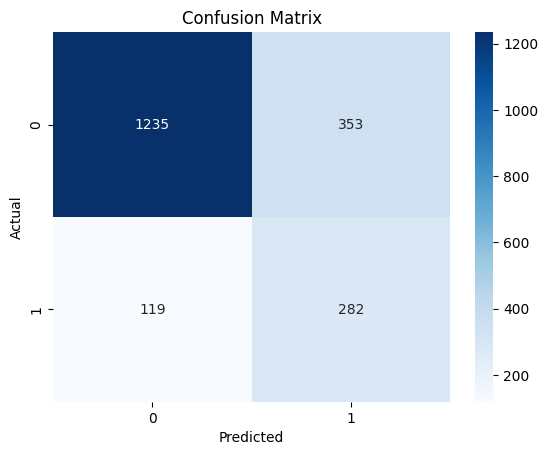

In [ ]:
# Valutazione del Modello con matrice di confusione
y_pred = dt_model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

METRICHE DI PERFORMANCE

PRECISION (precisione):

Precision = TP / TP + FP = 282 / 635 ≈ 44.5%

RECALL (stabilità):

Recall = TP / TP + FN = 282 / 401 ≈ 70%

**Recall (da 40% --> 70%):** Il nuovo modello bilanciato è molto più vigile: ora siamo in grado di intercettare il 70% dei clienti a rischio (282 su 401). I "Falsi Negativi" (i clienti persi silenziosamente) sono crollati da 239 a 119. Risultato: La banca ora ha l'opportunità di provare a salvare la grande maggioranza dei clienti insoddisfatti.

**Precision (da 69% --> 44.5%):** I falsi allarmi (Falsi Positivi) sono aumentati molto, passando da 74 a 353. Significato: la banca contatterà molti clienti fedeli pensando che vogliano andarsene.

# CONCLUSIONI

Il progetto ha portato allo sviluppo di due scenari predittivi distinti, la cui analisi comparata ci permette di definire la strategia operativa più efficace per la banca.

**La Scelta del Modello Operativo:**

Primo Scenario: Sebbene presenti un'accuratezza globale e una precisione elevata (70%), questo modello fallisce nell'obiettivo primario: la prevenzione dell'abbandono. Con una Recall del 40%, stiamo di fatto ignorando 6 clienti su 10 che stanno per lasciarci. Dal punto di vista manageriale, questo modello è inutilizzabile per campagne di retention, poiché lascia "scoperta" la maggior parte del rischio.

Secondo Scenario: Accettando un calo della precisione (più falsi allarmi), abbiamo alzato la Recall al 70%.

Decisione: Riteniamo il Secondo Scenario preferibile. Nel nostro caso, il costo di perdere un cliente è molto più alto del costo di fare una telefonata di cortesia a un cliente fedele (Falso Positivo). Preferiamo gestire più segnalazioni (anche errate) piuttosto che perdere silenziosamente la clientela.

**Profili di Rischio e Strategie di Fidelizzazione**

Adottando i risultati del secondo scenario, che massimizza la capacità di intercettare i clienti in uscita (Recall ~70%), abbiamo definito un piano d'azione basato sulle evidenze dell'Albero Decisionale. Il modello ci indica di agire su 3 leve specifiche:

**A. Stop Over-Selling (NumOfProducts > 2):** È il dato più sorprendente emerso dallo studio.

Possedere 2 prodotti è l'ottimo di stabilità. Superata questa soglia (3 o 4 prodotti), il tasso di abbandono esplode, diventando quasi una certezza per chi ne ha 4, indipendentemente dall'età.

Strategia: Bloccare le campagne di vendita sui clienti che hanno già 2 prodotti. Per chi ne ha già 3 o 4, proporre pacchetti di consolidamento (es. unificare i servizi) per semplificare la gestione, poiché la complessità è percepita come un disservizio.

**B. Fattore Età (42 anni):** L'età è la variabile più discriminante dell'intero dataset.

Sotto i 42 anni la clientela è stabile. Sopra questa soglia, e in particolare nella fascia 42-50 anni, il rischio aumenta notevolmente.

Strategia: Creare un programma "Seniority Reward". Al compimento del 40° anno, la banca deve contattare proattivamente il cliente per una revisione delle condizioni, anticipando la concorrenza.

**C. I clienti tedeschi e l'Inattività**

La Germania, anche per i profili giovani, mostra una rischiosità anomala che non vediamo in Francia o Spagna. Inoltre, l'inattività (IsActiveMember=0) è il precursore dell'abbandono per i Senior.

Germania: È necessaria un'indagine di mercato specifica. I competitor tedeschi offrono tassi migliori? Il nostro servizio clienti in Germania è carente? Il modello segnala un problema strutturale in questa regione.

Riattivazione: Non bisogna aspettare che il cliente chiuda il conto. Se un cliente over 40 diventa "Inattivo", deve scattare un trigger automatico (email/app) per stimolare un'interazione.

**Considerazioni Finali**

In conclusione, il progetto dimostra che non serve guardare al reddito (EstimatedSalary ha impatto quasi nullo) o al punteggio di credito per prevedere l'abbandono. La fedeltà nel nostro caso dipende dalla relazione (Attività), dalla semplicità (Numero Prodotti) e dall'età.

Il modello bilanciato sviluppato, pur generando un surplus operativo di falsi positivi, è lo strumento più idoneo per proteggere il portafoglio clienti della banca, permettendo alla banca di intervenire tempestivamente sul 70% dei potenziali abbandoni.